In [1]:
import pandas as pd
import numpy as np
import yfinance as yf

In [2]:
data = yf.download("AAPL", start="2024-01-01")

[*********************100%***********************]  1 of 1 completed


In [3]:
data.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.404022,186.170300,181.675100,184.895829,82488700
2024-01-03,182.030762,183.641134,181.220631,182.001124,58414500
2024-01-04,179.718948,180.884728,178.701356,179.956048,71983600
2024-01-05,178.997711,180.558682,177.999882,179.797968,62379700
2024-01-08,183.324982,183.364508,179.313886,179.896776,59144500


In [4]:
df=data.iloc[:,:-1]

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 667 entries, 2024-01-02 to 2026-08-28
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, AAPL)  667 non-null    float64
 1   (High, AAPL)   667 non-null    float64
 2   (Low, AAPL)    667 non-null    float64
 3   (Open, AAPL)   667 non-null    float64
dtypes: float64(4)
memory usage: 26.1 KB


In [6]:
import matplotlib.pyplot as plt

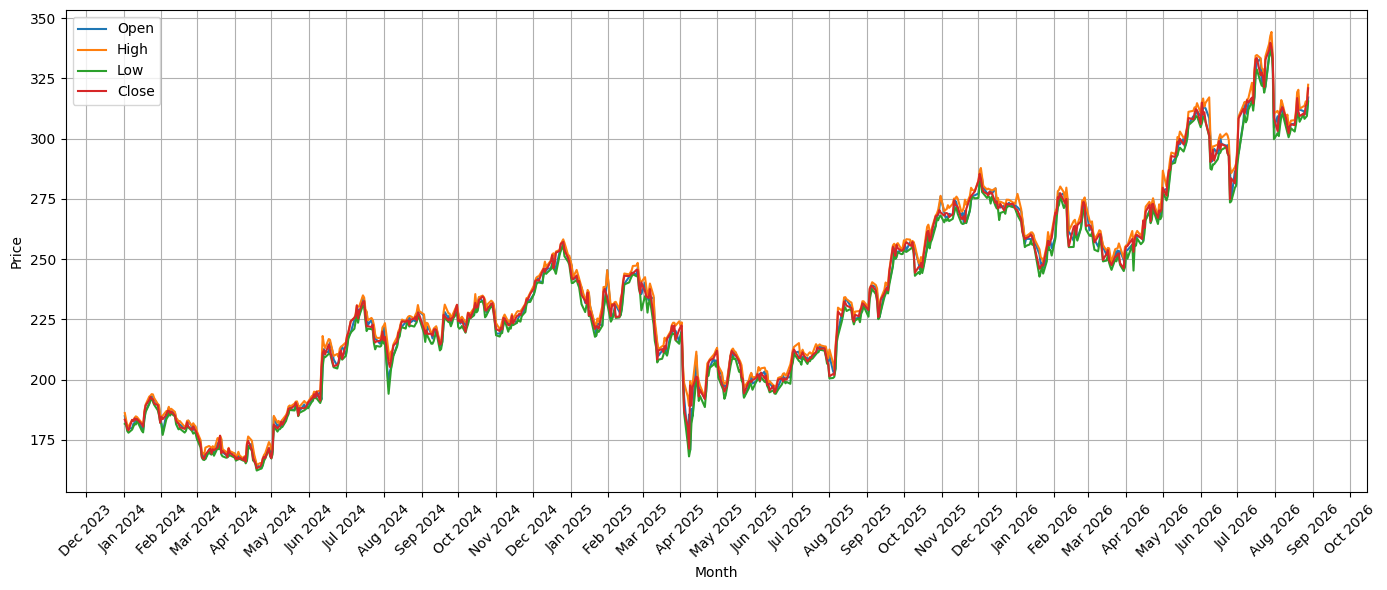

In [8]:

import matplotlib.dates as mdates
plt.figure(figsize=(14, 6))

for col in ['Open', 'High', 'Low', 'Close']:
    plt.plot(df.index, df[col], label=col)

ax = plt.gca() #Get Current Axes.
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) #%b = abbreviated month name %Y = four-digit year

plt.xlabel('Month')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

<Figure size 1400x800 with 0 Axes>

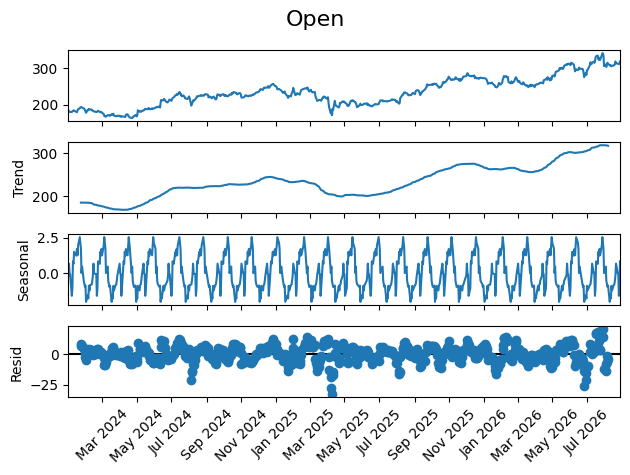

<Figure size 1400x800 with 0 Axes>

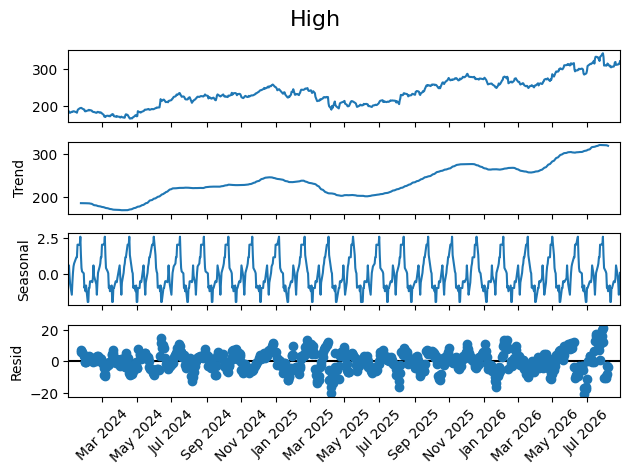

<Figure size 1400x800 with 0 Axes>

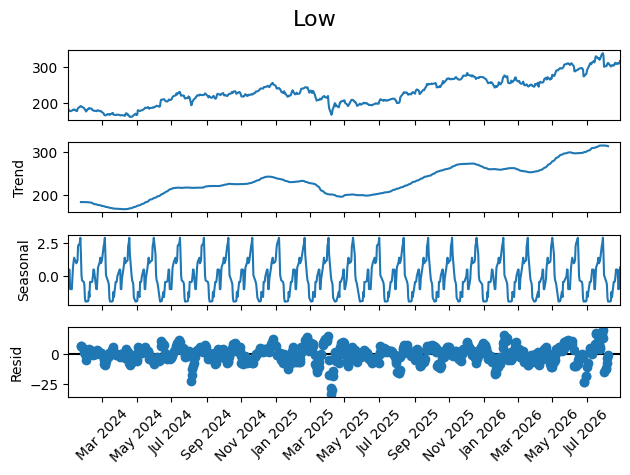

<Figure size 1400x800 with 0 Axes>

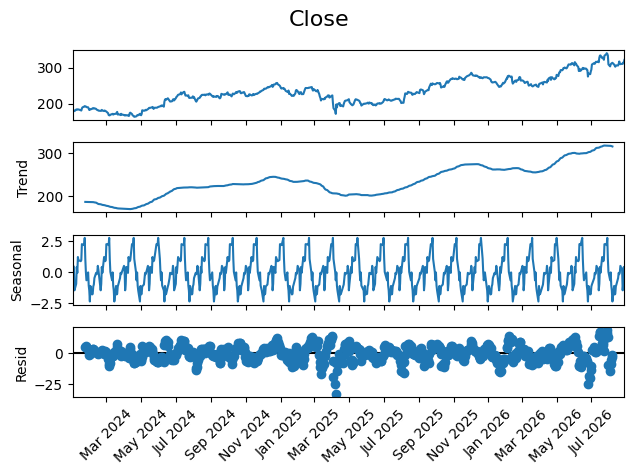

In [16]:
import matplotlib.dates as mdates
for col in ['Open', 'High', 'Low', 'Close']:

    result = seasonal_decompose(
        df[col],
        model='additive',
        period=30
    )

    # Create figure with desired size
    fig = plt.figure(figsize=(14, 8))

    # Plot decomposition
    result.plot()

    # Get all axes created by decomposition
    for ax in plt.gcf().axes:
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        ax.xaxis.set_major_formatter(
            mdates.DateFormatter('%b %Y')
        )
        ax.tick_params(axis='x', labelrotation=45)

    plt.suptitle(col, fontsize=16)
    plt.tight_layout()
    plt.show()

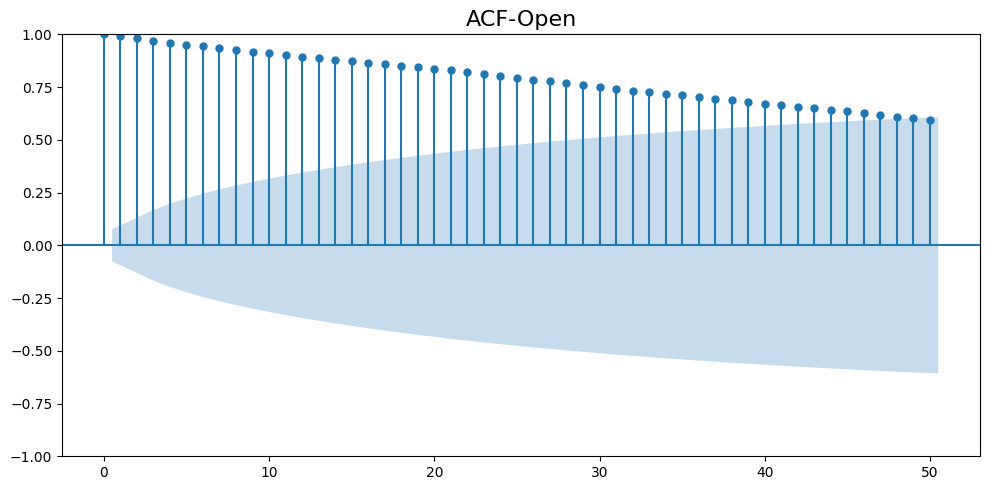

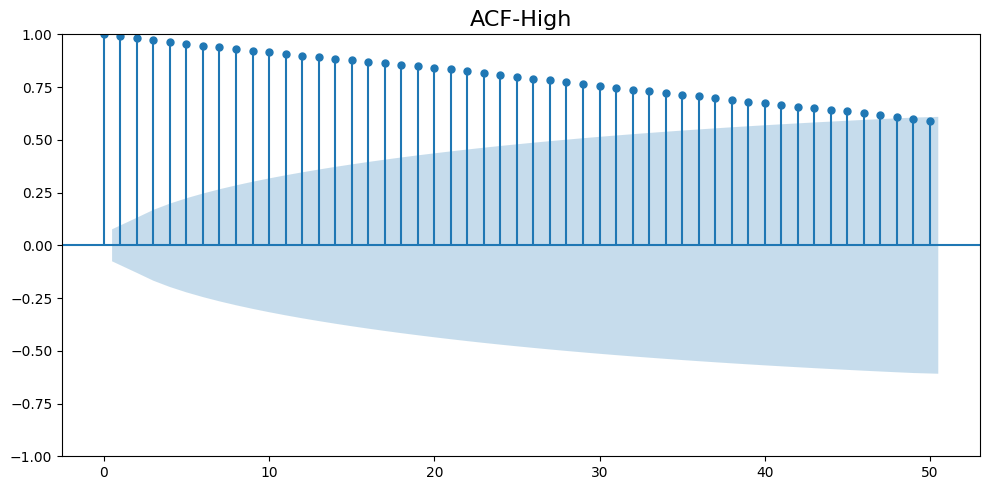

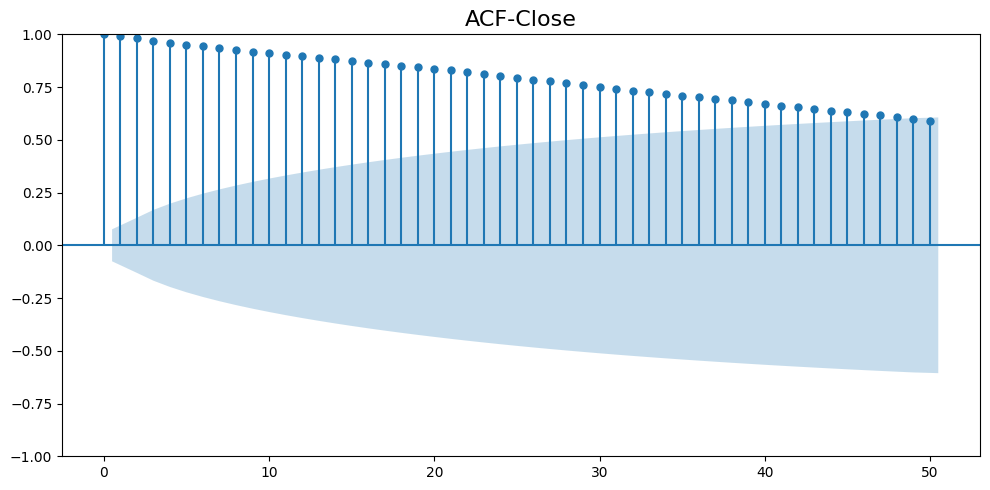

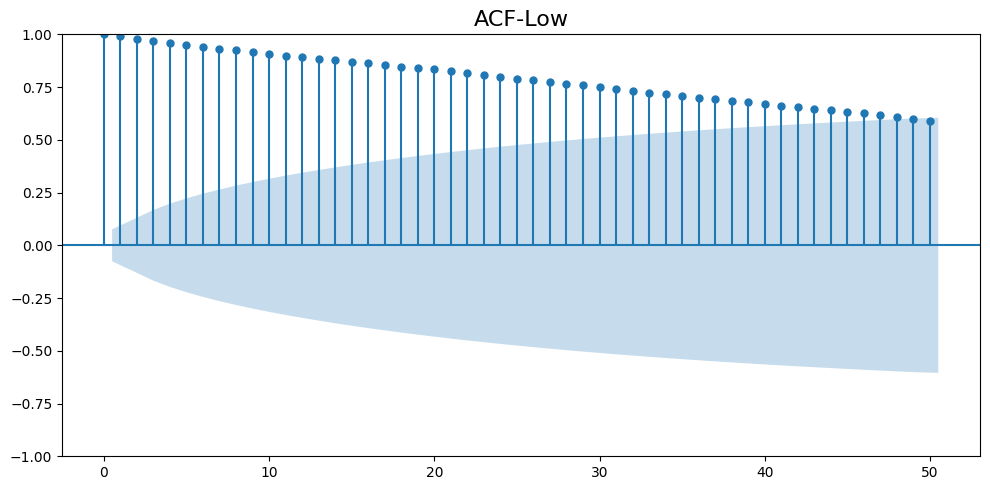

In [17]:
from statsmodels.graphics.tsaplots import plot_acf
for col in ['Open','High','Close','Low']:
    fig,ax=plt.subplots(figsize=(10,5))
    plot_acf(df[col].dropna(),lags=50,ax=ax)
    ax.set_title(f'ACF-{col}',fontsize=16)
    plt.tight_layout()
    plt.show()
    
    

In [18]:
from statsmodels.tsa.stattools import adfuller,kpss
def adf_test(series):
    adf_test=adfuller(series)
    print(f"adf stats:{round(adf_test[0],3)}")
    print(f"p-value stats:{round(adf_test[1],3)}")
   
        
def kpss_test(series):
    kpss_test=kpss(series,regression='ct')
    print("KPSS Statistic:", kpss_test[0])
    print("p-value:", kpss_test[1])
    

In [19]:
for col in ['Open', 'High', 'Low', 'Close']:
    adf_test(df[col])
    kpss_test(df[col])

adf stats:-0.869
p-value stats:0.798
KPSS Statistic: 0.325463028147445
p-value: 0.01
adf stats:-0.6
p-value stats:0.871
KPSS Statistic: 0.3270374699473832
p-value: 0.01
adf stats:-0.788
p-value stats:0.823
KPSS Statistic: 0.3252018612527836
p-value: 0.01
adf stats:-0.585
p-value stats:0.874
KPSS Statistic: 0.32625087529530417
p-value: 0.01


C:\Users\Mcc\AppData\Local\Temp\ipykernel_23032\915315252.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test=kpss(series,regression='ct')
C:\Users\Mcc\AppData\Local\Temp\ipykernel_23032\915315252.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test=kpss(series,regression='ct')
C:\Users\Mcc\AppData\Local\Temp\ipykernel_23032\915315252.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_test=kpss(series,regression='ct')
C:\Users\Mcc\AppData\Local\Temp\ipykernel_23032\915315252.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual 

In [20]:
df_diff=df.diff().dropna()

In [21]:
df_diff

Price,Close,High,Low,Open
Ticker,AAPL,AAPL,AAPL,AAPL
Date,,,,
2024-01-03,-1.373260,-2.529166,-0.454469,-2.894705
2024-01-04,-2.311813,-2.756405,-2.519276,-2.045076
2024-01-05,-0.721237,-0.326046,-0.701474,-0.158080
2024-01-08,4.327271,2.805826,1.314004,0.098808
2024-01-09,-0.414932,-0.444585,1.215188,1.807967
...,...,...,...,...
2026-08-24,0.989990,0.979980,2.959991,-0.579987
2026-08-25,-0.440002,0.230011,-1.760010,-0.679993


In [22]:
for col in ['Open', 'High', 'Low', 'Close']:
    adf_test(df_diff[col])
    kpss_test(df_diff[col])

adf stats:-15.73
p-value stats:0.0
KPSS Statistic: 0.038988738888192126
p-value: 0.1
adf stats:-13.954
p-value stats:0.0
KPSS Statistic: 0.04194372548333364
p-value: 0.1
adf stats:-13.957
p-value stats:0.0
KPSS Statistic: 0.037357174663154226
p-value: 0.1


C:\Users\Mcc\AppData\Local\Temp\ipykernel_23032\915315252.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test=kpss(series,regression='ct')
C:\Users\Mcc\AppData\Local\Temp\ipykernel_23032\915315252.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test=kpss(series,regression='ct')
C:\Users\Mcc\AppData\Local\Temp\ipykernel_23032\915315252.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test=kpss(series,regression='ct')


adf stats:-13.042
p-value stats:0.0
KPSS Statistic: 0.038143990032234454
p-value: 0.1


C:\Users\Mcc\AppData\Local\Temp\ipykernel_23032\915315252.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test=kpss(series,regression='ct')


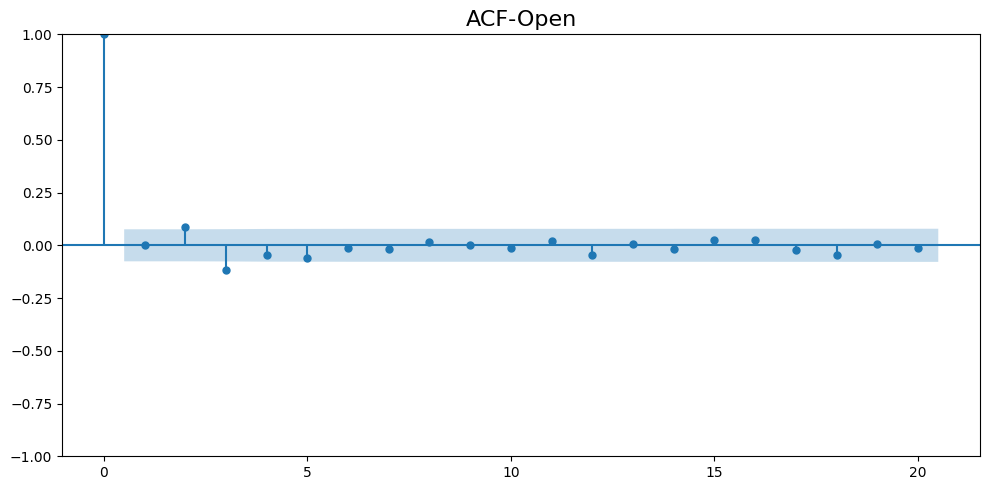

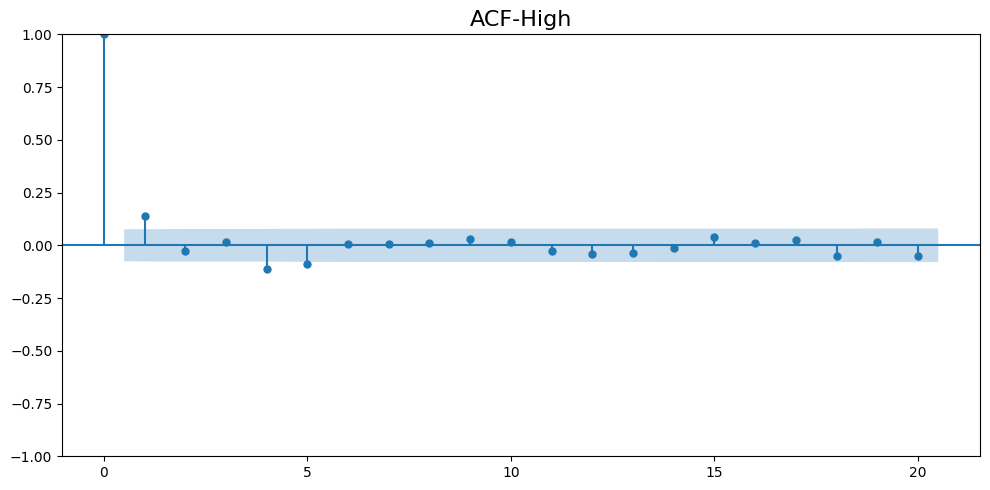

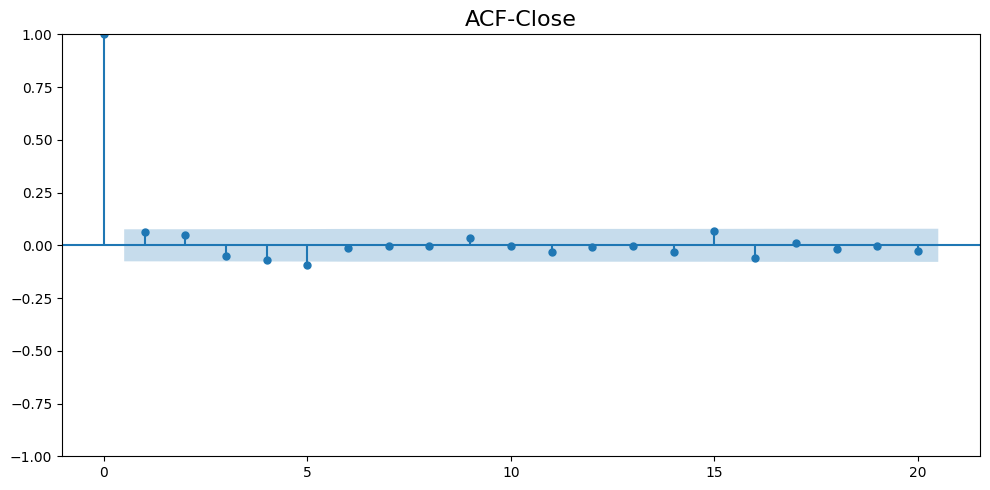

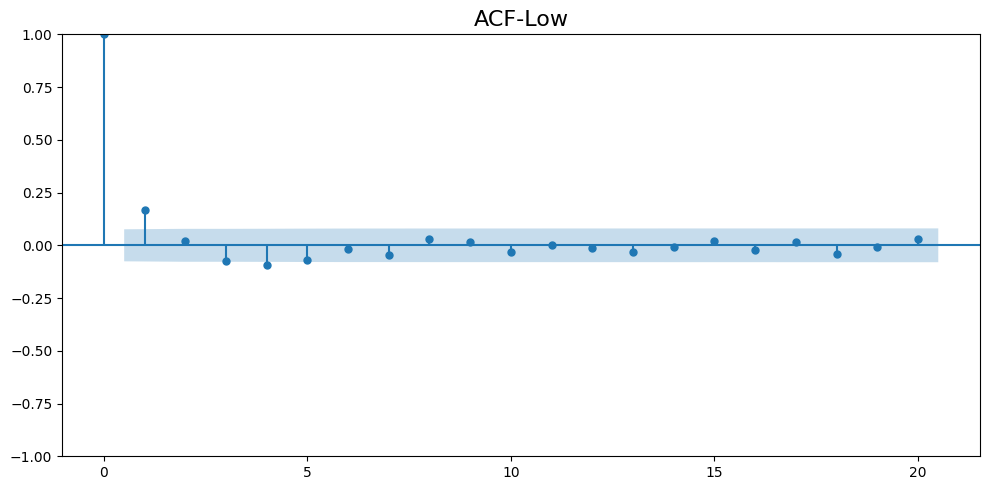

In [24]:
from statsmodels.graphics.tsaplots import plot_acf
for col in ['Open','High','Close','Low']:
    fig,ax=plt.subplots(figsize=(10,5))
    plot_acf(df_diff[col].dropna(),lags=20,ax=ax)
    ax.set_title(f'ACF-{col}',fontsize=16)
    plt.tight_layout()
    plt.show()
    

In [25]:
from statsmodels.tsa.api import VAR

In [26]:
train=df_diff[:600]
test=df_diff[600:]

In [27]:
model = VAR(train)

result = model.fit(maxlags=10, ic='aic')

print(result.k_ar)

6


C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [28]:
result = model.fit(maxlags=6)

print(result.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 28, Aug, 2026
Time:                     22:42:49
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    6.15455
Nobs:                     594.000    HQIC:                   5.70364
Log likelihood:          -4879.95    FPE:                    225.026
AIC:                      5.41602    Det(Omega_mle):         190.816
--------------------------------------------------------------------
Results for equation Close_AAPL
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                 0.216915         0.152135            1.426           0.154
L1.Close_AAPL         0.218397         0.111876            1.952           0.051
L1.High_AAPL         -0.221960         0.114517        

In [29]:
lag = result.k_ar

In [31]:
pred_test = result.forecast(
    train.values[-lag:],
    steps=len(test)
)


In [34]:
last_values=df.iloc[-1]
print(last_values)

Price  Ticker
Close  AAPL      320.899994
High   AAPL      322.369995
Low    AAPL      315.450409
Open   AAPL      317.088013
Name: 2026-08-28 00:00:00, dtype: float64


In [35]:
forecast_df = pd.DataFrame(
    pred_test,
    index=test.index,
    columns=test.columns
)

In [36]:
forecast_df

Price,Close,High,Low,Open
Ticker,AAPL,AAPL,AAPL,AAPL
Date,,,,
2026-05-27,-0.304299,-1.191515,-2.416557,-1.987243
2026-05-28,0.397406,0.065348,0.259690,-0.318476
2026-05-29,0.025772,-0.192032,0.300595,0.081870
2026-06-01,0.053382,0.348848,0.227438,0.336696
2026-06-02,0.020555,0.318028,0.338054,0.483992
...,...,...,...,...
2026-08-24,0.207804,0.210782,0.206943,0.207969
2026-08-25,0.207804,0.210782,0.206943,0.207969


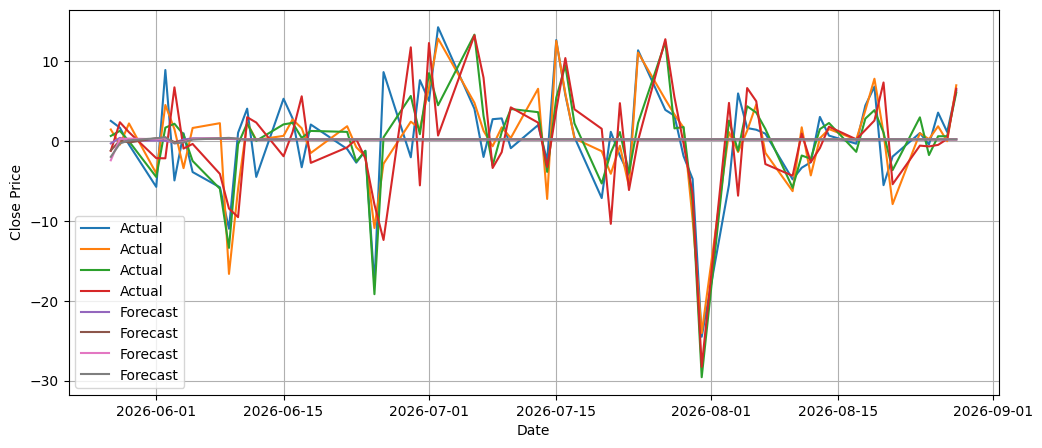

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(test.index,test, label='Actual')
plt.plot(test.index,forecast_df, label='Forecast')

plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid()
plt.show()

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(
    test,
    forecast_df
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast_df
    )
)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 4.169567682763031
RMSE: 6.150781580883778


In [46]:
last_price = df.iloc[-1]
forecast_price = forecast_df.cumsum() + last_price

In [47]:
steps = 10
lag = result.k_ar

forecast_diff = result.forecast(
    df_diff.values[-lag:],
    steps=steps
)
# Forecast differences → DataFrame
forecast_diff = pd.DataFrame(
    forecast_diff,
    columns=df.columns
)
# Last actual prices
last_values = df.iloc[-1]

# Reverse differencing
forecast_price = forecast_diff.cumsum().add(last_values)

# Future dates
future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=steps,
    freq='D'
)

forecast_price.index = future_dates

print(forecast_price)

Price            Close        High         Low        Open
Ticker            AAPL        AAPL        AAPL        AAPL
2026-08-29  322.689236  325.612189  319.543515  321.349827
2026-08-30  322.556119  325.475386  320.107111  323.074748
2026-08-31  322.791618  325.231083  319.499863  321.889023
2026-09-01  322.263022  324.627896  319.539159  322.056865
2026-09-02  322.284920  324.720325  318.860597  321.254802
2026-09-03  322.045650  324.869399  319.125753  321.905092
2026-09-04  322.181041  324.934405  319.049078  321.600051
2026-09-05  322.208527  324.979420  319.046123  321.621865
2026-09-06  322.516365  325.065725  319.239007  321.725645
2026-09-07  322.759256  325.307964  319.495244  321.955877
